In [137]:
import numpy as np
import networkx as nx
from scipy.special import logsumexp
from sklearn.metrics import normalized_mutual_info_score
import torch
import torch
import torch.nn.functional as F
from torch.special import digamma, gammaln
import matplotlib.pyplot as plt


# Bernoulli SBM

In [2]:
def binary_sbm_estimate(A, num_blocks, iter):
    gamma_prior = np.random.rand(num_blocks)
    gamma_prior = gamma_prior / np.sum(gamma_prior)
    
    beta = np.random.uniform(size = (num_blocks, num_blocks))

    gamma_posterior = np.random.rand(n, num_blocks)
    gamma_posterior = gamma_posterior / np.sum(gamma_posterior, axis=1, keepdims=True)
    print(gamma_posterior[0, :])
    for _ in range(iter):
        # E step
        gamma_posterior_temp = gamma_posterior.copy()
        log_gamma = np.zeros_like(gamma_posterior)
        for i in range(n):
            for k in range(num_blocks):
                term_1 = np.log(gamma_prior[k])
                term_2 = 0
                for j in range(n):
                    if j != i:
                        term_2 += np.sum(gamma_posterior[j, :]*(A[i, j]*np.log(beta[k, :]) + (1-A[i, j])*np.log(1-beta[k, :])))
                gamma_posterior_temp[i, k] = np.exp(term_1 + term_2)
                log_gamma[i, k] = term_1 + term_2
            log_gamma[i, :] = log_gamma[i, :] - logsumexp(log_gamma[i, :])
            gamma_posterior[i, :] = np.exp(log_gamma[i, :])




        ## Monte Carlo sample Z (community membership) -> to calculate the ELBO
        K = 1000
        samples = np.empty((n, K), dtype=np.int64)
        for i in range(n):
            samples[i] = np.random.choice(num_blocks, size=K, p=gamma_posterior[i])

        term_1 = 0        
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                else:
                    for l in range(num_blocks):
                        for k in range(num_blocks):
                            term_1 += gamma_posterior[i, l]*gamma_posterior[j, k]*(A[i, j]*np.log(beta[k, l]) + (1-A[i, j])*np.log(1-beta[k, l]))
        
        term_2 = 0
        for k in range(K):
            term_2 += np.sum(np.log(gamma_posterior[np.arange(n), samples[:, k]]))
        term_2 = term_2/K


        ELBO = term_1 + term_2
        print(f"ELBO: {ELBO}")

        # M step
        gamma_prior = np.average(gamma_posterior, axis=0)

        for k in range(num_blocks):
            for l in range(k, num_blocks):
                numerator = np.sum(np.outer(gamma_posterior[:,k],gamma_posterior[:,l]) * (1- np.eye(n)) * A)/2
                denominator = np.sum(np.outer(gamma_posterior[:,k],gamma_posterior[:,l]) * (1- np.eye(n)))/2
                beta[k, l] = numerator/denominator
                beta[l, k] = beta[k, l]

        print(gamma_prior)
        print(beta)
        # print(gamma_posterior)
    return gamma_posterior


In [10]:
seed = 0
# np.random.seed(0)


# Graph construction
block_sizes = [10,90]
num_blocks = len(block_sizes)

n = np.sum(block_sizes)
p = 1.5*n**(-0.3)
r = 0.15*n**(-0.3)
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")

probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

G = nx.stochastic_block_model(block_sizes, probs, seed=seed)
A = nx.to_numpy_array(G)


gamma_posterior = binary_sbm_estimate(A, num_blocks, 20)


# NMI
block_labels = np.array([d['block'] for _, d in G.nodes(data=True)])
predicted_labels = np.argmax(gamma_posterior, axis=1)
print(f"NMI: {normalized_mutual_info_score(block_labels, predicted_labels)}")


Intra prob: 0.376782964726437
Inter prob: 0.0376782964726437
[0.33925578 0.66074422]
ELBO: -17201.654500247758
[1.0000000e+00 4.8956953e-14]
[[0.30848485 0.0586803 ]
 [0.0586803  0.14304607]]
ELBO: -6117.031891815662
[9.99995923e-01 4.07679578e-06]
[[0.30848702 0.04265029]
 [0.04265029 0.00772452]]
ELBO: -5871.112886669062
[0.93068305 0.06931695]
[[0.34787    0.04843582]
 [0.04843582 0.25469093]]
ELBO: -5708.825540131699
[0.90000766 0.09999234]
[[0.36578857 0.05666292]
 [0.05666292 0.24444785]]
ELBO: -5701.901091676607
[0.90000044 0.09999956]
[[0.36579252 0.05666645]
 [0.05666645 0.24444464]]
ELBO: -5701.901090354541
[0.90000044 0.09999956]
[[0.36579252 0.05666645]
 [0.05666645 0.24444464]]
ELBO: -5701.90109035454
[0.90000044 0.09999956]
[[0.36579252 0.05666645]
 [0.05666645 0.24444464]]
ELBO: -5701.901090354397
[0.90000044 0.09999956]
[[0.36579252 0.05666645]
 [0.05666645 0.24444464]]
ELBO: -5701.901090354397
[0.90000044 0.09999956]
[[0.36579252 0.05666645]
 [0.05666645 0.24444464]]
E

# Bernoulli SBM - DP-SGD

In [149]:
import torch
import torch.nn.functional as F
from torch.special import digamma, gammaln


# ── DP helpers ────────────────────────────────────────────────────────────────

def clip_gradients(params, C):
    total_norm = torch.norm(
        torch.stack([p.grad.norm() for p in params if p.grad is not None])
    )
    scale = min(1.0, C / (total_norm.item() + 1e-8))
    for p in params:
        if p.grad is not None:
            p.grad.data.mul_(scale)
    return total_norm.item()


def add_gaussian_noise(params, sigma, C):
    for p in params:
        if p.grad is not None:
            p.grad.data.add_(torch.randn_like(p.grad) * sigma * C)


def accumulate_privacy(log_moments, sigma, q, max_lambda=32):
    for lam in range(1, max_lambda + 1):
        log_moments[lam] += (q ** 2 * lam * (lam + 1)) / ((1.0 - q) * sigma ** 2)
    return log_moments


def get_epsilon(log_moments, delta):
    import math
    return min(
        (log_moments[lam] - math.log(delta)) / lam
        for lam in log_moments
    )


# ── ELBO terms ────────────────────────────────────────────────────────────────

def elbo_L1(A, gamma_logits, log_alpha1, log_alpha2, i_idx, j_idx, temperature):
    """Likelihood term only — the only term that touches node pair data."""
    N, K = gamma_logits.shape
    gamma      = F.softmax(gamma_logits / temperature, dim=-1)
    alpha1     = F.softplus(log_alpha1)
    alpha2     = F.softplus(log_alpha2)
    alpha_sum  = alpha1 + alpha2
    E_log_b    = digamma(alpha1) - digamma(alpha_sum)
    E_log_1m_b = digamma(alpha2) - digamma(alpha_sum)

    total_pairs = N * (N - 1)
    scale       = total_pairs / len(i_idx)
    gamma_outer = gamma[i_idx].unsqueeze(2) * gamma[j_idx].unsqueeze(1)
    log_lik     = (A[i_idx, j_idx].view(-1, 1, 1) * E_log_b
                   + (1 - A[i_idx, j_idx]).view(-1, 1, 1) * E_log_1m_b)
    return scale * (gamma_outer * log_lik).sum()


def elbo_rest(gamma_logits, log_alpha1, log_alpha2, log_rho, temperature):
    """L2+L4+L5+L6+L7 — no node pair data, no clipping needed."""
    N, K = gamma_logits.shape
    gamma      = F.softmax(gamma_logits / temperature, dim=-1)
    alpha1     = F.softplus(log_alpha1)
    alpha2     = F.softplus(log_alpha2)
    rho        = F.softplus(log_rho)
    alpha_sum  = alpha1 + alpha2
    E_log_b    = digamma(alpha1) - digamma(alpha_sum)
    E_log_1m_b = digamma(alpha2) - digamma(alpha_sum)
    rho_0      = rho.sum()
    E_log_pi   = digamma(rho) - digamma(rho_0)

    L2 = (gamma * E_log_pi.unsqueeze(0)).sum()

    prior_alpha1 = torch.ones(K, K)
    prior_alpha2 = torch.ones(K, K)
    diag = torch.eye(K, dtype=torch.bool)
    prior_alpha1[diag]  = 10.0
    prior_alpha2[diag]  = 1.0
    prior_alpha1[~diag] = 1.0
    prior_alpha2[~diag] = 10.0
    prior_sum = prior_alpha1 + prior_alpha2
    L4 = ((prior_alpha1 - 1) * E_log_b
          + (prior_alpha2 - 1) * E_log_1m_b
          + gammaln(prior_sum) - gammaln(prior_alpha1) - gammaln(prior_alpha2)).sum()

    L5 = -(gamma * torch.log(gamma + 1e-10)).sum()

    L6 = -(gammaln(rho_0) - gammaln(rho).sum()
           - (rho_0 - K) * digamma(rho_0)
           + ((rho - 1) * digamma(rho)).sum())

    log_B = gammaln(alpha1) + gammaln(alpha2) - gammaln(alpha_sum)
    L7 = (log_B - (alpha1 - 1) * E_log_b - (alpha2 - 1) * E_log_1m_b).sum()

    return L2 + L4 + L5 + L6 + L7


def elbo_sampled(A, gamma_logits, log_alpha1, log_alpha2, log_rho, sample_pct=0.1, temperature=1.0):
    """Full ELBO — used by the non-DP path."""
    N = gamma_logits.shape[0]
    total_pairs = N * (N - 1)
    n_samples   = max(1, int(sample_pct * total_pairs))
    idx         = torch.randint(0, N, (n_samples * 2, 2))
    idx         = idx[idx[:, 0] != idx[:, 1]][:n_samples]
    i_idx, j_idx = idx[:, 0], idx[:, 1]

    L1   = elbo_L1(A, gamma_logits, log_alpha1, log_alpha2, i_idx, j_idx, temperature)
    rest = elbo_rest(gamma_logits, log_alpha1, log_alpha2, log_rho, temperature)
    return L1 + rest

# ── Training ──────────────────────────────────────────────────────────────────

def binary_sbm_estimate_fully_variational(
    A, num_blocks, iter, lr, lr_schedule=None, schedule_gamma=0.1, sample_pct=0.9,
    T_start=5.0, T_end=0.5,
    sigma=None, C=4.0, target_delta=1e-5,
):
    N = A.shape[0]
    K = num_blocks

    gamma_logits = torch.randn(N, K).requires_grad_(True)

    log_alpha1_init = torch.full((K, K), -3.0)
    log_alpha2_init = torch.full((K, K),  3.0)
    diag = torch.eye(K, dtype=torch.bool)
    log_alpha1_init[diag] =  3.0
    log_alpha2_init[diag] = -3.0
    log_alpha1 = log_alpha1_init.clone().requires_grad_(True)
    log_alpha2 = log_alpha2_init.clone().requires_grad_(True)
    log_rho    = torch.randn(K).requires_grad_(True)

    # # inject true block assignments
    # with torch.no_grad():
    #     true_gamma = torch.zeros(N, K)
    #     true_gamma[np.arange(N), block_labels] = 1.0
    #     gamma_logits.data = torch.log(true_gamma + 1e-6)


    # params for DP
    dp_params = [log_alpha1, log_alpha2] #[gamma_logits, log_alpha1, log_alpha2, log_rho]
    
    # params for full model
    full_params = [gamma_logits, log_alpha1, log_alpha2, log_rho]

    optimizer = torch.optim.Adam([
        {"params": [gamma_logits, log_rho],  "lr": lr,       "initial_lr": lr},
        {"params": [log_alpha1, log_alpha2], "lr": lr * 0.1, "initial_lr": lr * 0.1},
    ])

    total_pairs = N * (N - 1)
    n_samples   = max(1, int(sample_pct * total_pairs))
    q           = n_samples / total_pairs
    log_moments = {lam: 0.0 for lam in range(1, 33)}

    for step in range(iter):
        temperature = max(T_end, T_start * (T_end / T_start) ** (step / iter))

        if lr_schedule == "inverse":
            for pg in optimizer.param_groups:
                pg["lr"] = pg["initial_lr"] / (1.0 + schedule_gamma * step)

        # sample pairs once per step
        idx      = torch.randint(0, N, (n_samples * 2, 2))
        idx      = idx[idx[:, 0] != idx[:, 1]][:n_samples]
        i_idx, j_idx = idx[:, 0], idx[:, 1]

        if sigma is not None:

            # 1. backprop L1, clip, add noise, save
            optimizer.zero_grad()
            (-elbo_L1(A, gamma_logits, log_alpha1, log_alpha2,
                      i_idx, j_idx, temperature)).backward()
            clip_gradients(dp_params, C)
            add_gaussian_noise(dp_params, sigma, C)
            L1_grads = [p.grad.detach().clone() if p.grad is not None
                        else torch.zeros_like(p) for p in full_params]
 
            # 2. backprop rest, clip dp_params only (no noise — no private data)
            optimizer.zero_grad()
            (-elbo_rest(gamma_logits, log_alpha1, log_alpha2,
                        log_rho, temperature)).backward()
            clip_gradients(dp_params, C)
            rest_grads = [p.grad.detach().clone() if p.grad is not None
                          else torch.zeros_like(p) for p in full_params]
 
            # 3. combine: L1 (clipped+noised) + rest (clipped, no noise)
            for p, g_l1, g_rest in zip(full_params, L1_grads, rest_grads):
                p.grad = g_l1 + g_rest
 
            log_moments = accumulate_privacy(log_moments, sigma, q)

        else:
            optimizer.zero_grad()

            (-elbo_sampled(A, gamma_logits, log_alpha1, log_alpha2, log_rho,
                           sample_pct=sample_pct, temperature=temperature)).backward()
        
        torch.nn.utils.clip_grad_norm_(full_params, max_norm=10.0)

        if step % 20 == 0:
            with torch.no_grad():
                loss = elbo_sampled(A, gamma_logits, log_alpha1, log_alpha2, log_rho,
                                    sample_pct=sample_pct, temperature=temperature)
            print(f"Step {step} | loss: {loss.item():.4f} | temperature: {temperature:.3f}", end="")
            if sigma is not None:
                print(f" | ε={get_epsilon(log_moments, target_delta):.4f} δ={target_delta:.0e}", end="\n")



            # print("gamma_logits.grad norm:", gamma_logits.grad.norm().item())
            # print("gamma_logits.grad:\n", gamma_logits.grad)
            # print("log_alpha1.grad norm:", log_alpha1.grad.norm().item())
            # print("log_alpha1.grad:\n", log_alpha1.grad)
            # print("log_alpha2.grad norm:", log_alpha2.grad.norm().item())
            # print("log_alpha2.grad:\n", log_alpha2.grad)
            # print("log_rho.grad norm:", log_rho.grad.norm().item())
            # # print("log_rho.grad:\n", log_rho.grad)
            # print()
            print()

        optimizer.step()

    gamma_posterior     = F.softmax(gamma_logits / T_end, dim=-1).detach()
    rho_posterior       = F.softplus(log_rho).detach()
    alpha1_posterior    = F.softplus(log_alpha1).detach()
    alpha2_posterior    = F.softplus(log_alpha2).detach()
    beta_posterior_mean = alpha1_posterior / (alpha1_posterior + alpha2_posterior)

    return gamma_posterior, rho_posterior, beta_posterior_mean

In [151]:
block_labels     = np.array([d['block'] for _, d in G.nodes(data=True)])


In [214]:
seed = 0
# np.random.seed(seed)
# torch.manual_seed(seed)

# Graph construction
block_sizes = [50, 50]
num_blocks = len(block_sizes)

n = np.sum(block_sizes)
p = 1.5*n**(-0.3)
r = 0.15*n**(-0.3)
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")

probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

G = nx.stochastic_block_model(block_sizes, probs, seed=seed)
A = nx.to_numpy_array(G)

gamma_posterior, rho_posterior, beta_posterior_mean = binary_sbm_estimate_fully_variational(
    torch.tensor(A, dtype=torch.float32), num_blocks, 101, lr=10,
    lr_schedule="inverse", schedule_gamma=0.1, sample_pct=0.3, T_start=5.0, T_end=1.0, sigma=1, C=10.0, target_delta=1e-4
)

block_labels     = np.array([d['block'] for _, d in G.nodes(data=True)])
predicted_labels = np.argmax(gamma_posterior.numpy(), axis=1)
print(f"NMI: {normalized_mutual_info_score(block_labels, predicted_labels)}")
print(f"rho (posterior Dirichlet params): {rho_posterior.numpy()}")
print(f"pi (posterior mean): {(rho_posterior / rho_posterior.sum()).numpy()}")
print(f"\nbeta posterior mean (E[beta_kl]):")
print(np.round(beta_posterior_mean.numpy(), 3))

Intra prob: 0.376782964726437
Inter prob: 0.0376782964726437
Step 0 | loss: -109318.2656 | temperature: 5.000 | ε=2.3084 δ=1e-04

Step 20 | loss: -9004.9346 | temperature: 3.635 | ε=12.7052 δ=1e-04

Step 40 | loss: -6099.1045 | temperature: 2.643 | ε=19.7532 δ=1e-04

Step 60 | loss: -5760.6982 | temperature: 1.922 | ε=24.8961 δ=1e-04

Step 80 | loss: -5664.0601 | temperature: 1.397 | ε=30.0389 δ=1e-04

Step 100 | loss: -5641.8857 | temperature: 1.016 | ε=35.1818 δ=1e-04

NMI: 0.15412974927401074
rho (posterior Dirichlet params): [31.159851 44.940506]
pi (posterior mean): [0.40945736 0.5905426 ]

beta posterior mean (E[beta_kl]):
[[0.32  0.187]
 [0.178 0.274]]


## Experiments

# Bernoulli SBM - Fully variational with random group proportion - SGD

In [2]:
import torch
import torch.nn.functional as F
from torch.special import digamma, gammaln

In [ ]:
def elbo_sampled(A, gamma_logits, log_alpha1, log_alpha2, log_rho, sample_pct=0.1, temperature=1.0):
    N, K = gamma_logits.shape

    gamma = F.softmax(gamma_logits / temperature, dim=-1)  # <-- divide by temperature
    alpha1 = F.softplus(log_alpha1)
    alpha2 = F.softplus(log_alpha2)
    rho    = F.softplus(log_rho)                        # (K,), variational Dirichlet params

    alpha_sum  = alpha1 + alpha2
    E_log_b    = digamma(alpha1) - digamma(alpha_sum)
    E_log_1m_b = digamma(alpha2) - digamma(alpha_sum)

    rho_0      = rho.sum()
    E_log_pi   = digamma(rho) - digamma(rho_0)          # (K,), E_q[log pi_k]

    # --- sample random node pairs with i != j ---
    total_pairs = N * (N - 1)
    n_samples   = max(1, int(sample_pct * total_pairs))
    idx         = torch.randint(0, N, (n_samples * 2, 2))
    idx         = idx[idx[:, 0] != idx[:, 1]][:n_samples]
    i_idx, j_idx = idx[:, 0], idx[:, 1]
    n_pairs     = len(i_idx)
    scale       = total_pairs / n_pairs

    # 1. likelihood (scaled)
    gamma_i     = gamma[i_idx]
    gamma_j     = gamma[j_idx]
    A_ij        = A[i_idx, j_idx]
    gamma_outer = gamma_i.unsqueeze(2) * gamma_j.unsqueeze(1)   # (n_pairs, K, K)
    log_lik     = (A_ij.view(-1, 1, 1) * E_log_b
                   + (1 - A_ij).view(-1, 1, 1) * E_log_1m_b)
    L1 = scale * (gamma_outer * log_lik).sum()

    # 2. prior on Z: E_q[log p(Z|pi)] = sum_i sum_k gamma_ik * E_q[log pi_k]
    L2 = (gamma * E_log_pi.unsqueeze(0)).sum()

    # 3. prior on pi: E_q[log p(pi|eta)], Dirichlet(1,1,...) -> vanishes
    L3 = 0

    # 4. prior on beta - set diagonal beta toward 1 while off-diagonal beta toward 0 

    prior_alpha1 = torch.ones(K, K)
    prior_alpha2 = torch.ones(K, K)
    # Stronger intra-block prior
    diag = torch.eye(K, dtype=torch.bool)
    prior_alpha1[diag] = 3.0   # push diagonal beta toward 1
    prior_alpha2[diag] = 1.0
    prior_alpha1[~diag] = 1.0  # push off-diagonal beta toward 0
    prior_alpha2[~diag] = 3.0
    prior_sum = prior_alpha1 + prior_alpha2
    L4 = ((prior_alpha1 - 1) * E_log_b
        + (prior_alpha2 - 1) * E_log_1m_b
        + gammaln(prior_sum) - gammaln(prior_alpha1) - gammaln(prior_alpha2)).sum()

    # 5. entropy of q_Z
    L5 = -(gamma * torch.log(gamma + 1e-10)).sum()

    # 6. entropy of q_pi (negative KL)
    L6 = -(gammaln(rho_0) - gammaln(rho).sum()
           - (rho_0 - K) * digamma(rho_0)
           + ((rho - 1) * digamma(rho)).sum())

    # 7. entropy of q_beta
    log_B = gammaln(alpha1) + gammaln(alpha2) - gammaln(alpha_sum)
    L7 = (log_B - (alpha1 - 1) * E_log_b - (alpha2 - 1) * E_log_1m_b).sum()

    return L1 + L2 + L3 + L4 + L5 + L6 + L7

In [143]:
def binary_sbm_estimate_fully_variational(
    A, num_blocks, iter, lr, schedule_gamma=0.1, sample_pct=0.9, 
    T_start=5.0, T_end=0.5, 
    gamma_steps=5, beta_steps=5
):
    N = A.shape[0]
    K = num_blocks

    ###  Initialization
    gamma_logits = torch.randn(N, K).requires_grad_(True)

    # Initialize alphas so that intra probs are higher than inter probs
    log_alpha1_init = torch.full((K, K), 3.0)  # default: low alpha1 (inter)
    log_alpha2_init = torch.full((K, K),  10.0)  # default: high alpha2 (inter)
    diag = torch.eye(K, dtype=torch.bool)
    log_alpha1_init[diag] = 10.0   # high alpha1 on diagonal
    log_alpha2_init[diag] = 3.0   # low alpha2 on diagonal
    log_alpha1 = log_alpha1_init.clone().requires_grad_(True)
    log_alpha2 = log_alpha2_init.clone().requires_grad_(True)

    log_rho = (torch.randn(K) + 3.0).requires_grad_(True)


    # optimizer = torch.optim.Adam([gamma_logits, log_alpha1, log_alpha2, log_rho], lr=lr)
    optimizer_gamma = torch.optim.Adam([
        {"params": [gamma_logits], "lr": lr, "initial_lr": lr},
    ])
    optimizer_beta = torch.optim.Adam([
        {"params": [log_rho],              "lr": lr * 0.5, "initial_lr": lr * 0.5},
        {"params": [log_alpha1, log_alpha2], "lr": lr * 0.5, "initial_lr": lr * 0.5},
    ])
    
    for step in range(iter):
        # temperature = max(T_end, T_start - (T_start - T_end) * (step / iter))

        for pg in optimizer_gamma.param_groups + optimizer_beta.param_groups:
            pg["lr"] = pg["initial_lr"] / (1.0 + schedule_gamma * step)

        # --- gamma step ---
        for gamma_step in range(gamma_steps):
            for pg in optimizer_gamma.param_groups:
                pg["lr"] = pg["initial_lr"] / (1.0 + schedule_gamma * gamma_step)
            temperature = max(T_end, T_start - (T_start - T_end) * (gamma_step / gamma_steps))

            optimizer_gamma.zero_grad()
            (-elbo_sampled(A, gamma_logits, log_alpha1, log_alpha2, log_rho,
                           sample_pct=sample_pct, temperature=temperature)
            ).backward()
            torch.nn.utils.clip_grad_norm_([gamma_logits], max_norm=10.0)
            optimizer_gamma.step()

        # --- beta/rho step ---
        for beta_step in range(beta_steps):
            for pg in optimizer_beta.param_groups:
                pg["lr"] = pg["initial_lr"] / (1.0 + schedule_gamma * beta_step)
            optimizer_beta.zero_grad()
            (-elbo_sampled(A, gamma_logits, log_alpha1, log_alpha2, log_rho,
                        sample_pct=sample_pct, temperature=1)
            ).backward()
            torch.nn.utils.clip_grad_norm_([log_rho, log_alpha1, log_alpha2], max_norm=10.0)
            optimizer_beta.step()

        if step % 20 == 0:
            print(f"Step {step} loss: {(-elbo_sampled(A, gamma_logits, log_alpha1, log_alpha2, log_rho, sample_pct=sample_pct, temperature=1)).item():.4f} ")

    gamma_posterior = F.softmax(gamma_logits / T_end, dim=-1).detach()
    rho_posterior   = F.softplus(log_rho).detach()
    alpha1_posterior = F.softplus(log_alpha1).detach()
    alpha2_posterior = F.softplus(log_alpha2).detach()
    # print(f"Alpha1_posterior: {alpha1_posterior}")
    # print(f"Alpha2_posterior: {alpha2_posterior}")
    beta_posterior_mean = alpha1_posterior / (alpha1_posterior + alpha2_posterior)

    return gamma_posterior, rho_posterior, beta_posterior_mean

In [136]:
seed = 0
# np.random.seed(seed)
# torch.manual_seed(seed)

# Graph construction
block_sizes = [290,120,350]
# block_sizes = [100, 100]
# block_sizes = [50,50,50,50,50,50]

num_blocks = len(block_sizes)

n = np.sum(block_sizes)
p = 1.5*n**(-0.3)
r = 0.15*n**(-0.3)
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")

probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

G = nx.stochastic_block_model(block_sizes, probs, seed=seed)
A = nx.to_numpy_array(G)

true_beta = torch.tensor(probs, dtype=torch.float32)  # (K, K)
gamma_posterior, rho_posterior, beta_posterior_mean = binary_sbm_estimate_fully_variational(
    torch.tensor(A, dtype=torch.float32), num_blocks, iter=100, lr=3,
    schedule_gamma=0.1, sample_pct=0.1, T_start=80.0, T_end=1.0, gamma_steps=20, beta_steps=5
)

block_labels     = np.array([d['block'] for _, d in G.nodes(data=True)])
predicted_labels = np.argmax(gamma_posterior.numpy(), axis=1)
print(f"NMI: {normalized_mutual_info_score(block_labels, predicted_labels)}")
print(f"rho (posterior Dirichlet params): {rho_posterior.numpy()}")
print(f"pi (posterior mean): {(rho_posterior / rho_posterior.sum()).numpy()}")
print(f"\nbeta posterior mean (E[beta_kl]):")
print(np.round(beta_posterior_mean.numpy(), 3))

Intra prob: 0.2050440547164194
Inter prob: 0.02050440547164194
Step 0 loss: 190401.0938 
Step 20 loss: 150414.0938 
Step 40 loss: 149409.3594 
Step 60 loss: 148015.4844 
Step 80 loss: 152162.7656 
Alpha1_posterior: tensor([[59.0019,  7.7466,  6.1766],
        [ 8.4927, 46.8790,  6.4778],
        [ 6.0681,  5.8321, 32.6415]])
Alpha2_posterior: tensor([[224.8979, 365.8541, 320.3500],
        [363.8822, 183.0709, 302.3499],
        [303.6675, 302.2427, 127.9119]])
NMI: 1.0
rho (posterior Dirichlet params): [130.76007 108.87142  45.41105]
pi (posterior mean): [0.4587388  0.38194796 0.15931323]

beta posterior mean (E[beta_kl]):
[[0.208 0.021 0.019]
 [0.023 0.204 0.021]
 [0.02  0.019 0.203]]


In [134]:
block_sizes/n

array([0.38157895, 0.15789474, 0.46052632])

In [135]:
gamma_posterior


tensor([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]])

## Experiments

In [53]:
import contextlib
import io
from sklearn.cluster import SpectralClustering

N_NODES = 200
NUM_BLOCKS = 2
N_RUNS = 5
METHOD_SEEDS = list(range(N_RUNS))
GRAPH_SEED = 42

VI_ITER = 200
VI_LR = 1.0
VI_KWARGS = dict(
    lr_schedule="inverse",
    schedule_gamma=0.01,
    sample_pct=0.7,
    T_start=5.0,
    T_end=0.5,
)

GRAPH_CONFIGS = [
    {"case": 1, "p": 0.4, "r": 0.02, "group_proportions": [0.5, 0.5]},
    {"case": 2, "p": 0.4, "r": 0.02, "group_proportions": [0.65, 0.35]},
    {"case": 3, "p": 0.4, "r": 0.1, "group_proportions": [0.5, 0.5]},
    {"case": 4, "p": 0.12, "r": 0.08, "group_proportions": [0.5, 0.5]},
]


def make_sbm_graph(p, r, group_proportions, graph_seed):
    block_sizes = [int(round(N_NODES * prop)) for prop in group_proportions]
    block_sizes[-1] = N_NODES - sum(block_sizes[:-1])
    probs = np.eye(NUM_BLOCKS) * p + (1 - np.eye(NUM_BLOCKS)) * r
    G = nx.stochastic_block_model(block_sizes, probs, seed=graph_seed)
    A = nx.to_numpy_array(G)
    block_labels = np.array([d["block"] for _, d in G.nodes(data=True)])
    return G, A, block_labels, block_sizes


def run_vi(A, method_seed):
    torch.manual_seed(method_seed)
    np.random.seed(method_seed)
    A_t = torch.tensor(A, dtype=torch.float32)
    with contextlib.redirect_stdout(io.StringIO()):
        gamma_posterior, _, _ = binary_sbm_estimate_fully_variational(
            A_t, NUM_BLOCKS, VI_ITER, lr=VI_LR, **VI_KWARGS
        )
    predicted_labels = np.argmax(gamma_posterior.numpy(), axis=1)
    return predicted_labels


def run_spectral(A, method_seed):
    spectral = SpectralClustering(
        n_clusters=NUM_BLOCKS,
        affinity="precomputed",
        random_state=method_seed,
    )
    return spectral.fit_predict(A)


for cfg in GRAPH_CONFIGS:
    p = cfg["p"]
    r = cfg["r"]
    group_proportions = cfg["group_proportions"]
    case = cfg["case"]

    _, A, block_labels, block_sizes = make_sbm_graph(
        p, r, group_proportions, GRAPH_SEED
    )

    vi_nmis = []
    spectral_nmis = []
    for method_seed in METHOD_SEEDS:
        vi_pred = run_vi(A, method_seed)
        vi_nmis.append(normalized_mutual_info_score(block_labels, vi_pred))

        spectral_pred = run_spectral(A, method_seed)
        spectral_nmis.append(normalized_mutual_info_score(block_labels, spectral_pred))

    print("=" * 72)
    print(f"Case {case}")
    print(f"  n = {N_NODES}")
    print(f"  p (intra) = {p}")
    print(f"  r (inter) = {r}")
    print(f"  group proportions = {group_proportions}")
    print(f"  block sizes = {block_sizes}")
    print(f"  graph seed = {GRAPH_SEED} (fixed across runs)")
    print(f"  method seeds = {METHOD_SEEDS}")
    print()
    print("  binary_sbm_estimate_fully_variational NMI:")
    for i, nmi in enumerate(vi_nmis):
        print(f"    run {i + 1} (seed={METHOD_SEEDS[i]}): {nmi:.6f}")
    print(f"    mean: {np.mean(vi_nmis):.6f}  std: {np.std(vi_nmis):.6f}")
    print()
    print("  SpectralClustering (sklearn) NMI:")
    for i, nmi in enumerate(spectral_nmis):
        print(f"    run {i + 1} (seed={METHOD_SEEDS[i]}): {nmi:.6f}")
    print(f"    mean: {np.mean(spectral_nmis):.6f}  std: {np.std(spectral_nmis):.6f}")
    print()

Case 1
  n = 200
  p (intra) = 0.4
  r (inter) = 0.02
  group proportions = [0.5, 0.5]
  block sizes = [100, 100]
  graph seed = 42 (fixed across runs)
  method seeds = [0, 1, 2, 3, 4]

  binary_sbm_estimate_fully_variational NMI:
    run 1 (seed=0): 1.000000
    run 2 (seed=1): 1.000000
    run 3 (seed=2): 1.000000
    run 4 (seed=3): 1.000000
    run 5 (seed=4): 0.000000
    mean: 0.800000  std: 0.400000

  SpectralClustering (sklearn) NMI:
    run 1 (seed=0): 1.000000
    run 2 (seed=1): 1.000000
    run 3 (seed=2): 1.000000
    run 4 (seed=3): 1.000000
    run 5 (seed=4): 1.000000
    mean: 1.000000  std: 0.000000

Case 2
  n = 200
  p (intra) = 0.4
  r (inter) = 0.02
  group proportions = [0.65, 0.35]
  block sizes = [130, 70]
  graph seed = 42 (fixed across runs)
  method seeds = [0, 1, 2, 3, 4]

  binary_sbm_estimate_fully_variational NMI:
    run 1 (seed=0): 1.000000
    run 2 (seed=1): 1.000000
    run 3 (seed=2): 1.000000
    run 4 (seed=3): 1.000000
    run 5 (seed=4): 1.000

Generating SBM graph …
Graph generated: torch.Size([1000, 1000]), density=0.109

=== iter=50 ===
Step 0 loss: 354779.9062 
Step 20 loss: 302427.5000 
Step 40 loss: 299847.3125 
Step 0 loss: 341486.2500 
Step 20 loss: 298772.0312 
Step 40 loss: 303416.5625 
Step 0 loss: 348470.1562 
Step 20 loss: 302696.2500 
Step 40 loss: 299745.0312 
Step 0 loss: 371653.6562 
Step 20 loss: 302967.4062 
Step 40 loss: 302541.0625 
Step 0 loss: 356186.2812 
Step 20 loss: 302398.5312 
Step 40 loss: 297564.6562 
Step 0 loss: 381851.2188 
Step 20 loss: 306127.0000 
Step 40 loss: 300021.9062 
Step 0 loss: 364332.2500 
Step 20 loss: 302537.8750 
Step 40 loss: 300124.1250 
Step 0 loss: 342471.6562 
Step 20 loss: 305120.3125 
Step 40 loss: 300940.8750 
Step 0 loss: 345078.5625 
Step 20 loss: 304749.8750 
Step 40 loss: 300572.5000 
Step 0 loss: 375792.1562 
Step 20 loss: 301914.5312 
Step 40 loss: 302880.5625 
Step 0 loss: 358793.4688 
Step 20 loss: 302903.8438 
Step 40 loss: 302858.6562 
Step 0 loss: 369306.437

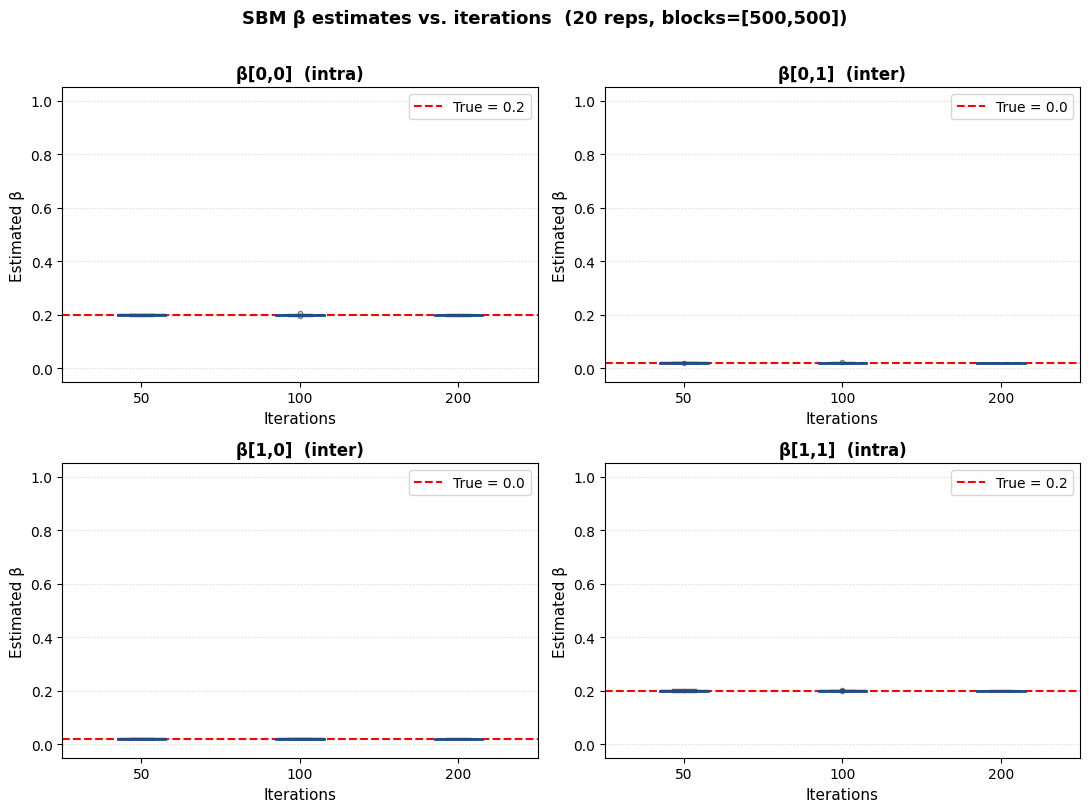

In [144]:
# ── data generation ───────────────────────────────────────────────────────────

def generate_sbm(block_sizes, beta_true):
    """Sample a binary adjacency matrix from an SBM."""
    N = sum(block_sizes)
    K = len(block_sizes)
    labels = torch.cat([torch.full((s,), k) for k, s in enumerate(block_sizes)])
    A = torch.zeros(N, N)
    for i in range(N):
        for j in range(i + 1, N):
            p = beta_true[labels[i], labels[j]].item()
            e = float(torch.rand(1) < p)
            A[i, j] = A[j, i] = e
    return A

# ── experiment ────────────────────────────────────────────────────────────────

BLOCK_SIZES  = [500, 500]
K            = len(BLOCK_SIZES)
REPS         = 20
ITER_VALUES  = [50, 100, 200]
LR           = 3.0
SAMPLE_PCT   = 0.1
SCHEDULE_GAMMA = 0.1
T_START      = 80.0
T_END        = 1.0
GAMMA_STEPS  = 20
BETA_STEPS   = 5

# True beta matrix
beta_true = torch.tensor([[0.20, 0.02],
                           [0.02, 0.20]])

# Unique beta values to track: (0,0)=intra, (0,1)=inter, (1,1)=intra
# We'll track all 4 entries but they come in two distinct values.
# For plotting we track the three unique entries: [0,0], [0,1], [1,1]
ENTRIES = [(0, 0), (0, 1), (1, 0), (1, 1)]
TRUE_VALS = {(r, c): beta_true[r, c].item() for (r, c) in ENTRIES}

# results[iter_val][(r,c)] = list of estimated values across reps
results = {it: {e: [] for e in ENTRIES} for it in ITER_VALUES}

# Generate one fixed graph (re-used across iter conditions for comparability)
print("Generating SBM graph …")
A = generate_sbm(BLOCK_SIZES, beta_true)
print(f"Graph generated: {A.shape}, density={A.mean():.3f}")

for it in ITER_VALUES:
    print(f"\n=== iter={it} ===")
    for rep in range(REPS):
        print(f"  rep {rep+1}/{REPS}", end="\r")
        _, _, beta_est = binary_sbm_estimate_fully_variational(
            A, num_blocks=K, iter=it, lr=LR,
            schedule_gamma=SCHEDULE_GAMMA, sample_pct=SAMPLE_PCT,
            T_start=T_START, T_end=T_END,
            gamma_steps=GAMMA_STEPS, beta_steps=BETA_STEPS,
        )
        for (r, c) in ENTRIES:
            results[it][(r, c)].append(beta_est[r, c].item())
    print(f"  done")


# ── plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=False)
axes = axes.flatten()

entry_labels = {(0,0): "β[0,0]  (intra)",
                (0,1): "β[0,1]  (inter)",
                (1,0): "β[1,0]  (inter)",
                (1,1): "β[1,1]  (intra)"}

for ax, (r, c) in zip(axes, ENTRIES):
    data    = [results[it][(r, c)] for it in ITER_VALUES]
    pos     = list(range(1, len(ITER_VALUES) + 1))

    bp = ax.boxplot(data, positions=pos, patch_artist=True,
                    boxprops=dict(facecolor="#a8c8f8", alpha=0.8),
                    medianprops=dict(color="#1a4e8a", linewidth=2),
                    whiskerprops=dict(color="#555"),
                    capprops=dict(color="#555"),
                    flierprops=dict(marker="o", markersize=3, alpha=0.5))

    ax.axhline(TRUE_VALS[(r, c)], color="red", linestyle="--",
               linewidth=1.5, label=f"True = {TRUE_VALS[(r,c)]:.1f}")

    ax.set_xticks(pos)
    ax.set_xticklabels(ITER_VALUES)
    ax.set_xlabel("Iterations", fontsize=11)
    ax.set_ylabel("Estimated β", fontsize=11)
    ax.set_title(entry_labels[(r, c)], fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.set_ylim(-0.05, 1.05)
    
fig.suptitle("SBM β estimates vs. iterations  (20 reps, blocks=[500,500])",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("sbm_beta_boxplot.png", dpi=150, bbox_inches="tight")
print("\nPlot saved to sbm_beta_boxplot.png")
plt.show()


Plot saved to sbm_beta_boxplot.png


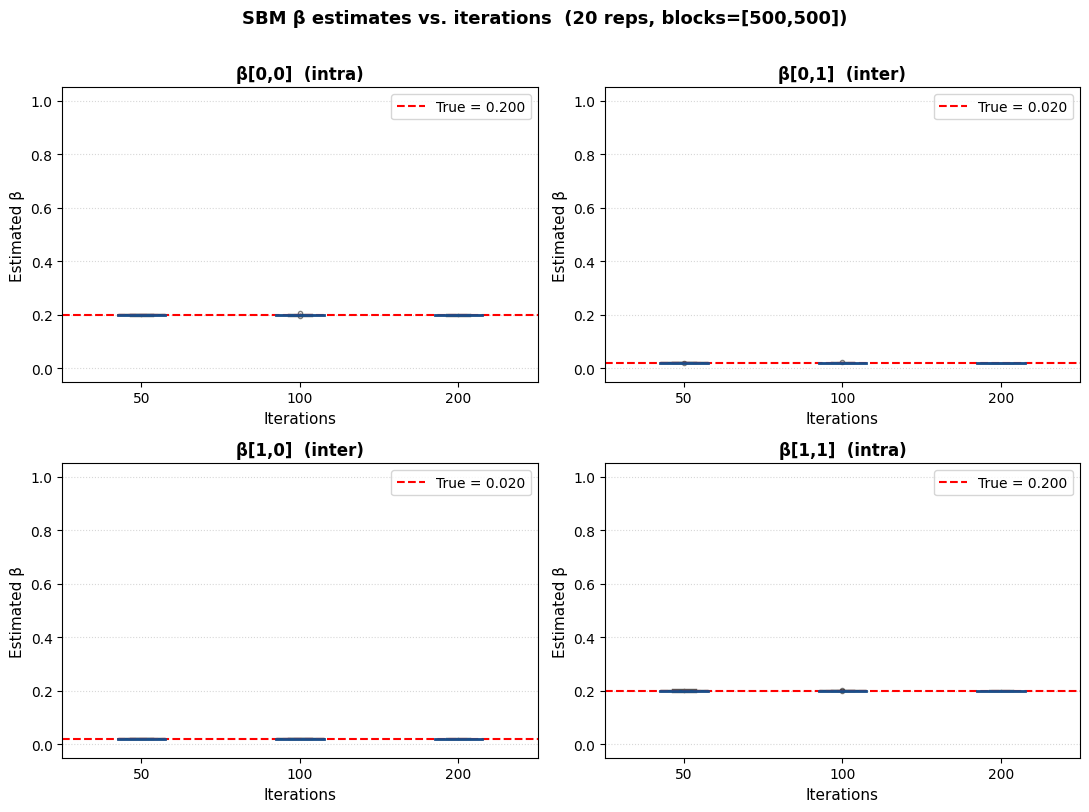

In [145]:
# ── plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=False)
axes = axes.flatten()

entry_labels = {(0,0): "β[0,0]  (intra)",
                (0,1): "β[0,1]  (inter)",
                (1,0): "β[1,0]  (inter)",
                (1,1): "β[1,1]  (intra)"}

for ax, (r, c) in zip(axes, ENTRIES):
    data    = [results[it][(r, c)] for it in ITER_VALUES]
    pos     = list(range(1, len(ITER_VALUES) + 1))

    bp = ax.boxplot(data, positions=pos, patch_artist=True,
                    boxprops=dict(facecolor="#a8c8f8", alpha=0.8),
                    medianprops=dict(color="#1a4e8a", linewidth=2),
                    whiskerprops=dict(color="#555"),
                    capprops=dict(color="#555"),
                    flierprops=dict(marker="o", markersize=3, alpha=0.5))

    ax.axhline(TRUE_VALS[(r, c)], color="red", linestyle="--",
               linewidth=1.5, label=f"True = {TRUE_VALS[(r,c)]:.3f}")

    ax.set_xticks(pos)
    ax.set_xticklabels(ITER_VALUES)
    ax.set_xlabel("Iterations", fontsize=11)
    ax.set_ylabel("Estimated β", fontsize=11)
    ax.set_title(entry_labels[(r, c)], fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.set_ylim(-0.05, 1.05)
    
fig.suptitle("SBM β estimates vs. iterations  (20 reps, blocks=[500,500])",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("sbm_beta_boxplot.png", dpi=150, bbox_inches="tight")
print("\nPlot saved to sbm_beta_boxplot.png")
plt.show()

# Bernoulli SBM - Fully variational - SGD

In [3]:
import torch
import torch.nn.functional as F
from torch.special import digamma, gammaln

In [5]:
def elbo_sampled(A, gamma_logits, log_alpha1, log_alpha2, sample_pct=0.1):
    N, K = gamma_logits.shape

    gamma  = F.softmax(gamma_logits, dim=-1)
    alpha1 = F.softplus(log_alpha1)
    alpha2 = F.softplus(log_alpha2)

    alpha_sum  = alpha1 + alpha2
    E_log_b    = digamma(alpha1) - digamma(alpha_sum)
    E_log_1m_b = digamma(alpha2) - digamma(alpha_sum)

    # --- sample random node pairs with i != j ---
    total_pairs = N * (N - 1)
    n_samples   = max(1, int(sample_pct * total_pairs))

    idx    = torch.randint(0, N, (n_samples * 2, 2))
    idx    = idx[idx[:, 0] != idx[:, 1]][:n_samples]
    i_idx, j_idx = idx[:, 0], idx[:, 1]

    n_pairs = len(i_idx)
    scale   = total_pairs / n_pairs                 # unbiased scaling

    # 1. likelihood (scaled)
    gamma_i = gamma[i_idx]                          # (n_pairs, K)
    gamma_j = gamma[j_idx]                          # (n_pairs, K)
    A_ij    = A[i_idx, j_idx]                       # (n_pairs,)

    gamma_outer = (gamma_i.unsqueeze(2) *
                   gamma_j.unsqueeze(1))             # (n_pairs, K, K)
    log_lik     = (A_ij.view(-1, 1, 1) * E_log_b
                   + (1 - A_ij).view(-1, 1, 1) * E_log_1m_b)

    L1 = scale * (gamma_outer * log_lik).sum()

    # 2. prior on Z
    L2 = -N * torch.log(torch.tensor(float(K), dtype=torch.float32))

    # 4. entropy of q_Z
    L4 = -(gamma * torch.log(gamma + 1e-10)).sum()

    # 5. entropy of q_beta
    log_B = gammaln(alpha1) + gammaln(alpha2) - gammaln(alpha_sum)
    L5 = (log_B - (alpha1 - 1) * E_log_b - (alpha2 - 1) * E_log_1m_b).sum()

    return L1 + L2 + L4 + L5

In [6]:
def binary_sbm_estimate_fully_variational(
    A, num_blocks, iter, lr, lr_schedule=None, schedule_gamma=0.1, sample_pct=0.9
):
    """
    A: adjacency matrix
    lr_schedule: None (constant lr) or "inverse" for lr / (1 + schedule_gamma * step),
        same form as binary_sbm_estimate_E_step_GD.
    """
    N = A.shape[0]
    K = num_blocks

    gamma_logits = (torch.randn(N, K) * 1).detach().requires_grad_(True)
    log_alpha1   = torch.zeros(K, K, requires_grad=True)
    log_alpha2   = torch.zeros(K, K, requires_grad=True)

    optimizer = torch.optim.Adam([gamma_logits, log_alpha1, log_alpha2], lr=lr)

    for step in range(iter):
        if lr_schedule == "inverse":
            lr_t = lr / (1.0 + schedule_gamma * step)
            for pg in optimizer.param_groups:
                pg["lr"] = lr_t
        optimizer.zero_grad()
        loss = -elbo_sampled(A, gamma_logits, log_alpha1, log_alpha2, sample_pct=sample_pct)
        loss.backward()
        optimizer.step()
        print(f"Step {step} loss: {loss.item()}")

    gamma_posterior = F.softmax(gamma_logits, dim=-1).detach().numpy()
    return gamma_posterior


In [7]:
seed = 0
# np.random.seed(seed)
# torch.manual_seed(seed)

# Graph construction
block_sizes = [100,100]
num_blocks = len(block_sizes)

n = np.sum(block_sizes)
p = 1.5*n**(-0.3)
r = 0.15*n**(-0.3)
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")

probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

G = nx.stochastic_block_model(block_sizes, probs, seed=seed)
A = nx.to_numpy_array(G)


# Estimate
gamma_posterior = binary_sbm_estimate_fully_variational(
    torch.tensor(A), num_blocks, 5000, lr=1,
    lr_schedule="inverse",
    schedule_gamma=0.03,
    sample_pct=0.9
)

# NMI
block_labels = np.array([d['block'] for _, d in G.nodes(data=True)])
predicted_labels = np.argmax(gamma_posterior, axis=1)
print(f"NMI: {normalized_mutual_info_score(block_labels, predicted_labels)}")

Intra prob: 0.30604286600525543
Inter prob: 0.030604286600525544
Step 0 loss: 46365.29378196696
Step 1 loss: 33198.05465039844
Step 2 loss: 31506.95229272377
Step 3 loss: 26572.605773298383
Step 4 loss: 23890.6775574913
Step 5 loss: 22968.452868883203
Step 6 loss: 22543.721983939402
Step 7 loss: 22199.191581215375
Step 8 loss: 21559.07503691381
Step 9 loss: 21343.007031751484
Step 10 loss: 20887.55034967746
Step 11 loss: 20641.338437950937
Step 12 loss: 20674.18843735359
Step 13 loss: 20350.45837248526
Step 14 loss: 20572.4025702252
Step 15 loss: 20055.255040405686
Step 16 loss: 20021.770433836922
Step 17 loss: 20060.47006044324
Step 18 loss: 20104.44891783725
Step 19 loss: 20110.237644605488
Step 20 loss: 20088.36378273382
Step 21 loss: 20079.40021235479
Step 22 loss: 19718.477429289178
Step 23 loss: 19775.46077450155
Step 24 loss: 19836.914790304247
Step 25 loss: 19810.438237692535
Step 26 loss: 19519.074895502592
Step 27 loss: 19641.706780185217
Step 28 loss: 19624.699662118044
Step

In [7]:
gamma_posterior

array([[2.4272035e-07, 9.9999976e-01],
       [2.2778850e-06, 9.9999774e-01],
       [1.6007779e-06, 9.9999845e-01],
       [1.8934595e-06, 9.9999809e-01],
       [1.2766035e-06, 9.9999869e-01],
       [1.5827711e-06, 9.9999845e-01],
       [1.9358733e-06, 9.9999809e-01],
       [2.6178186e-06, 9.9999738e-01],
       [2.2573149e-06, 9.9999774e-01],
       [2.3528544e-06, 9.9999762e-01],
       [1.5506248e-06, 9.9999845e-01],
       [2.0941459e-06, 9.9999785e-01],
       [1.3508460e-06, 9.9999869e-01],
       [2.5647234e-06, 9.9999738e-01],
       [2.2162781e-06, 9.9999774e-01],
       [1.2818811e-06, 9.9999869e-01],
       [1.2254412e-06, 9.9999881e-01],
       [2.4836640e-06, 9.9999750e-01],
       [1.7077640e-06, 9.9999833e-01],
       [2.7817514e-06, 9.9999726e-01],
       [1.8069295e-06, 9.9999821e-01],
       [4.1732116e-07, 9.9999952e-01],
       [1.7392871e-06, 9.9999821e-01],
       [1.5559561e-06, 9.9999845e-01],
       [1.7852498e-06, 9.9999821e-01],
       [2.8854663e-06, 9.

# Bernoulli SBM - SGD E-Step

In [8]:
# Vectorized version
def binary_sbm_estimate_E_step_GD(A, num_blocks, iter, lr, mini_batch_p_sample):
    """
    A: adjacency matrix
    num_blocks: number of blocks
    iter: number of iterations
    K: number of Monte Carlo samples
    lr: learning rate
    beta[k,l] = P(A_ij=1 | z_i=k, z_j=l); kept symmetric (init and M-step).
    """

    gamma_prior = np.random.rand(num_blocks)
    gamma_prior = gamma_prior / np.sum(gamma_prior)

    beta = np.random.uniform(size=(num_blocks, num_blocks))
    beta = (beta + beta.T) / 2.0
    # Unconstrained logits, gamma_posterior = softmax(logits) so gamma_posterior is a probability distribution
    logits = torch.randn(n, num_blocks, dtype=torch.double, requires_grad=True)
    A_torch = torch.as_tensor(A, dtype=torch.double, device=logits.device)

    for t in range(iter):
        # E step — gradient ascent on ELBO w.r.t. logits
        # Learning-rate schedule
        lr_t = lr / (1.0 + 0.1 * t)

        gamma_posterior_torch = torch.nn.functional.softmax(logits, dim=1)
        beta_torch = torch.as_tensor(beta, dtype=torch.double, device=logits.device)
        log_beta = torch.log(beta_torch.clamp(min=1e-15))
        log_one_minus_beta = torch.log((1.0 - beta_torch).clamp(min=1e-15))

        # Upper-triangle pairs (i < j)
        i_idx, j_idx = torch.triu_indices(n, n, offset=1, device=logits.device)
        g_i = gamma_posterior_torch[i_idx]
        g_j = gamma_posterior_torch[j_idx]
        a_ij = A_torch[i_idx, j_idx]
        log_bern = (
            a_ij[:, None, None] * log_beta[None, :, :]
            + (1.0 - a_ij)[:, None, None] * log_one_minus_beta[None, :, :]
        )
        pair_mask = torch.bernoulli(
            torch.full(
                (i_idx.shape[0],),
                mini_batch_p_sample,
                dtype=logits.dtype,
                device=logits.device,
            )
        )
        edge_terms = torch.einsum("ek,ekl,el->e", g_i, log_bern, g_j)
        term_1 = (edge_terms * pair_mask).sum()

        term_2 = (gamma_posterior_torch * torch.log(gamma_posterior_torch.clamp(min=1e-15))).sum()

        ELBO = term_1 - term_2
        print(f"ELBO: {ELBO}")

        ELBO.backward()
        print("grad_norm:", logits.grad.norm().item())

        with torch.no_grad():
            logits.add_(lr_t * logits.grad)
        logits.grad.zero_()
        gamma_posterior = torch.nn.functional.softmax(logits.detach(), dim=1).cpu().numpy()


        # M step
        gamma_prior = np.average(gamma_posterior, axis=0)
        # gamma_prior = block_sizes/np.sum(block_sizes)

        # beta = probs
        for k in range(num_blocks):
            for l in range(k, num_blocks):
                numerator = np.sum(np.outer(gamma_posterior[:,k],gamma_posterior[:,l]) * (1- np.eye(n)) * A)/2
                denominator = np.sum(np.outer(gamma_posterior[:,k],gamma_posterior[:,l]) * (1- np.eye(n)))/2
                beta[k, l] = numerator/denominator
                beta[l, k] = beta[k, l]

    return gamma_posterior, gamma_prior, beta


In [59]:
seed = 0
# np.random.seed(seed)
# torch.manual_seed(seed)

# Graph construction
block_sizes = [50,50]
num_blocks = len(block_sizes)

n = np.sum(block_sizes)
p = 1.5*n**(-0.3)
r = 0.15*n**(-0.3)
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")

probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

G = nx.stochastic_block_model(block_sizes, probs, seed=seed)
A = nx.to_numpy_array(G)


# Estimate
gamma_posterior, gamma_prior, beta = binary_sbm_estimate_E_step_GD(A, num_blocks, 40, lr = 0.1, mini_batch_p_sample = 0.8)

# NMI
block_labels = np.array([d['block'] for _, d in G.nodes(data=True)])
predicted_labels = np.argmax(gamma_posterior, axis=1)
print(f"NMI: {normalized_mutual_info_score(block_labels, predicted_labels)}")


Intra prob: 0.376782964726437
Inter prob: 0.0376782964726437
ELBO: -2060.914771680404
grad_norm: 6.435706693351839
ELBO: -1916.4205267765208
grad_norm: 2.39712171657678
ELBO: -1904.0841143044681
grad_norm: 2.373507662602153
ELBO: -1920.8350141929104
grad_norm: 2.3565709069085083
ELBO: -1941.7972110123194
grad_norm: 2.322449337515328
ELBO: -1884.3340290440292
grad_norm: 2.3223015557390405
ELBO: -1910.6987466417975
grad_norm: 2.285930540404052
ELBO: -1896.3223808827586
grad_norm: 2.274088652826453
ELBO: -1891.799900788259
grad_norm: 2.249073515960657
ELBO: -1916.416222489827
grad_norm: 2.261701267054256
ELBO: -1890.348139440746
grad_norm: 2.229085436689063
ELBO: -1905.6780968374756
grad_norm: 2.22625630316405
ELBO: -1891.0298288283616
grad_norm: 2.2074349407975813
ELBO: -1948.713594654074
grad_norm: 2.1932925661568974
ELBO: -1918.9474906909209
grad_norm: 2.1794501257701167
ELBO: -1924.1459304197656
grad_norm: 2.1708804212960597
ELBO: -1922.2381196554406
grad_norm: 2.164243395304858
ELBO:

In [ ]:
# Not vectorized version
def binary_sbm_estimate_E_step_GD(A, num_blocks, iter, lr, mini_batch_p_sample):
    """
    A: adjacency matrix
    num_blocks: number of blocks
    iter: number of iterations
    K: number of Monte Carlo samples
    lr: learning rate
    """
    gamma_prior = np.random.rand(num_blocks)
    gamma_prior = gamma_prior / np.sum(gamma_prior)
    
    beta = np.random.uniform(size=(num_blocks, num_blocks))
    beta = (beta + beta.T) / 2.0
    # Unconstrained logits, gamma_posterior = softmax(logits) so gamma_posterior is a probability distribution
    logits = torch.randn(n, num_blocks, dtype=torch.double, requires_grad=True)
    A_torch = torch.as_tensor(A, dtype=torch.double, device=logits.device)

    for t in range(iter):
        # E step — gradient ascent on ELBO w.r.t. logits
        # Learning-rate schedule
        lr_t = lr / (1.0 + 0.1 * t)

        gamma_posterior_torch = torch.nn.functional.softmax(logits, dim=1)
        beta_torch = torch.as_tensor(beta, dtype=torch.double)

        term_1 = 0        
        for i in range(n):
            for j in range(i+1,n):
                is_sampled = bool(np.random.choice(2, size=1, p=[1 - mini_batch_p_sample, mini_batch_p_sample]))
                if not is_sampled:
                    continue
                elif i == j:
                    continue
                else:
                    for l in range(num_blocks):
                        for k in range(num_blocks):
                            term_1 += gamma_posterior_torch[i, k]*gamma_posterior_torch[j, l]*(A_torch[i, j]*torch.log(beta_torch[k, l]) + (1-A_torch[i, j])*torch.log(1-beta_torch[k, l]))


        term_2 = 0
        for i in range(n):
            for l in range(num_blocks):
                term_2 += gamma_posterior_torch[i,l]*torch.log(gamma_posterior_torch[i,l])

        ELBO = term_1 + term_2
        print(f"ELBO: {ELBO}")

        ELBO.backward()
        print("grad_norm:", logits.grad.norm().item())

        with torch.no_grad():
            logits.add_(lr_t * logits.grad)
        logits.grad.zero_()
        gamma_posterior = torch.nn.functional.softmax(logits.detach(), dim=1).cpu().numpy()


        # M step
        gamma_prior = np.average(gamma_posterior, axis=0)
        # gamma_prior = block_sizes/np.sum(block_sizes)

        # beta = probs
        for k in range(num_blocks):
            for l in range(k, num_blocks):
                numerator = np.sum(np.outer(gamma_posterior[:,k],gamma_posterior[:,l]) * (1- np.eye(n)) * A)/2
                denominator = np.sum(np.outer(gamma_posterior[:,k],gamma_posterior[:,l]) * (1- np.eye(n)))/2
                beta[k, l] = numerator/denominator
                beta[l, k] = beta[k, l]

    return gamma_posterior, gamma_prior, beta

In [41]:
seed = 0
# np.random.seed(seed)
# torch.manual_seed(seed)

# Graph construction
block_sizes = [30,70]
num_blocks = len(block_sizes)

n = np.sum(block_sizes)
p = 1.5*n**(-0.3)
r = 0.15*n**(-0.3)
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")

probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

G = nx.stochastic_block_model(block_sizes, probs, seed=seed)
A = nx.to_numpy_array(G)


# Estimate
gamma_posterior, gamma_prior, beta = binary_sbm_estimate_E_step_GD(A, num_blocks, 40, lr = 0.1, mini_batch_p_sample = 0.8)

# NMI
block_labels = np.array([d['block'] for _, d in G.nodes(data=True)])
predicted_labels = np.argmax(gamma_posterior, axis=1)
print(f"NMI: {normalized_mutual_info_score(block_labels, predicted_labels)}")


Intra prob: 0.376782964726437
Inter prob: 0.0376782964726437
ELBO: -2814.650252285396
grad_norm: 52.972506987009595
ELBO: -2064.343549698502
grad_norm: 2.723325317039129
ELBO: -2081.2167273067744
grad_norm: 2.7737158831695594
ELBO: -2045.593769511317
grad_norm: 2.6190793488379294
ELBO: -2038.916572144861
grad_norm: 2.7109558427395655
ELBO: -2071.636756703682
grad_norm: 2.78717544393921
ELBO: -2022.5051119602451
grad_norm: 2.6971511318160184
ELBO: -2066.321155815896
grad_norm: 2.715024670767362
ELBO: -2061.6163596516694
grad_norm: 2.7705432150369407
ELBO: -2046.4234327328813
grad_norm: 2.7615939217455883
ELBO: -2074.981562568259
grad_norm: 2.8072997734159437
ELBO: -2075.116293018241
grad_norm: 2.838435762829359
ELBO: -2076.9480515325317
grad_norm: 2.7990587622338214
ELBO: -2071.5583581654096
grad_norm: 2.757924323959586
ELBO: -2063.88369719194
grad_norm: 2.854568736590935
ELBO: -2077.951284482759
grad_norm: 2.8497735488681917
ELBO: -2069.1187670863997
grad_norm: 2.8991034193915106
ELBO:

In [413]:
gamma_posterior

array([[0.00824453, 0.99175547],
       [0.00841812, 0.99158188],
       [0.99312603, 0.00687397],
       [0.99364772, 0.00635228],
       [0.00744277, 0.99255723],
       [0.00917948, 0.99082052],
       [0.99460946, 0.00539054],
       [0.99272487, 0.00727513],
       [0.99336613, 0.00663387],
       [0.99166068, 0.00833932],
       [0.99153999, 0.00846001],
       [0.9927163 , 0.0072837 ],
       [0.99396689, 0.00603311],
       [0.99225207, 0.00774793],
       [0.0088546 , 0.9911454 ],
       [0.99320683, 0.00679317],
       [0.99132671, 0.00867329],
       [0.99328073, 0.00671927],
       [0.99163792, 0.00836208],
       [0.99369354, 0.00630646],
       [0.99399453, 0.00600547],
       [0.00731192, 0.99268808],
       [0.99253027, 0.00746973],
       [0.00993315, 0.99006685],
       [0.00683478, 0.99316522],
       [0.99394841, 0.00605159],
       [0.00628127, 0.99371873],
       [0.99094621, 0.00905379],
       [0.99355704, 0.00644296],
       [0.99282094, 0.00717906],
       [0.

In [414]:
beta

array([[0.22535955, 0.21967876],
       [0.21967876, 0.25353357]])

In [410]:
gamma_prior

array([0.97920786, 0.02079214])

In [411]:
block_labels = np.array([d['block'] for _, d in G.nodes(data=True)])
predicted_labels = np.argmax(gamma_posterior, axis=1)
print(f"NMI: {normalized_mutual_info_score(block_labels, predicted_labels)}")


NMI: 0.020371257409514718


# Poisson SBM

In [26]:
seed = 0
np.random.seed(seed)
pi_true = np.array([0.3, 0.7])
num_blocks = 2

n = 200
p = 3
r = 0.5
print(f"Intra lambda: {p}")
print(f"Inter lambda: {r}")

lambdas = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

z = np.random.choice(num_blocks, size=n, p=pi_true)
A = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(i + 1, n):
        lambda_param = lambdas[z[i], z[j]]
        A[i, j] = np.random.poisson(lam=lambda_param)
        A[j, i] = A[i, j]


Intra lambda: 3
Inter lambda: 0.5


In [27]:
def poisson_sbm_estimate(A, num_blocks, iter):
    
    # Initialize parameters
    gamma_prior = np.random.rand(num_blocks)
    gamma_prior = gamma_prior / np.sum(gamma_prior)
    
    lambda_param = np.random.poisson(lam=int(np.average(A)), size = (2,2)).astype(float)

    gamma_posterior = np.random.rand(n, num_blocks)
    gamma_posterior = gamma_posterior / np.sum(gamma_posterior, axis=1, keepdims=True)

    
    print(gamma_prior)
    
    # EM
    for _ in range(iter):
        # E step
        log_gamma = np.zeros_like(gamma_posterior)
        for i in range(n):
            for k in range(num_blocks):
                term_1 = np.log(gamma_prior[k])
                term_2 = 0
                for j in range(n):
                    if j != i:
                        term_2 += np.sum(gamma_posterior[j, :]*(A[i, j]*np.log(lambda_param[k, :]) - lambda_param[k, :]))
                log_gamma[i, k] = term_1 + term_2

            log_gamma[i, :] = log_gamma[i, :] - logsumexp(log_gamma[i, :])
            gamma_posterior[i, :] = np.exp(log_gamma[i, :])

        # M step
        gamma_prior = np.average(gamma_posterior, axis=0)

        for k in range(num_blocks):
            for l in range(k, num_blocks):
                numerator = np.sum(np.outer(gamma_posterior[:,k], gamma_posterior[:,l]) * (1- np.eye(n)) * A)/2
                denominator = np.sum(np.outer(gamma_posterior[:,k], gamma_posterior[:,l]) * (1- np.eye(n)))/2
                lambda_param[k, l] = numerator/denominator
                lambda_param[l, k] = lambda_param[k, l]

        print(gamma_prior)

    return gamma_posterior


In [28]:
np.random.seed(0)
gamma_posterior = poisson_sbm_estimate(A, num_blocks, 20)

[0.43418691 0.56581309]
[0.28854617 0.71145383]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]
[0.305 0.695]


In [ ]:
block_labels = z
predicted_labels = np.argmax(gamma_posterior, axis=1)
print(f"NMI: {normalized_mutual_info_score(block_labels, predicted_labels)}")


NMI: 1.0


# Poisson SBM - Fully variational with random group proportion - SGD

In [7]:
def elbo_sampled_poisson(A, gamma_logits, log_alpha, log_tau, log_rho,
                         sample_pct=0.1, temperature=1.0):
    N, K = gamma_logits.shape

    gamma  = F.softmax(gamma_logits / temperature, dim=-1)
    alpha  = F.softplus(log_alpha)       # (K, K), variational Gamma shape
    tau    = F.softplus(log_tau)         # (K, K), variational Gamma rate
    rho    = F.softplus(log_rho)         # (K,),   variational Dirichlet params

    E_log_lam = digamma(alpha) - torch.log(tau)   # (K, K), E_q[log lambda_kl]
    E_lam     = alpha / tau                        # (K, K), E_q[lambda_kl]

    rho_0    = rho.sum()
    E_log_pi = digamma(rho) - digamma(rho_0)       # (K,)

    # --- sample random node pairs with i != j ---
    total_pairs = N * (N - 1)
    n_samples   = max(1, int(sample_pct * total_pairs))
    idx         = torch.randint(0, N, (n_samples * 2, 2))
    idx         = idx[idx[:, 0] != idx[:, 1]][:n_samples]
    i_idx, j_idx = idx[:, 0], idx[:, 1]
    n_pairs     = len(i_idx)
    scale       = total_pairs / n_pairs

    # 1. likelihood (scaled): E_q[A_ij * log(lambda) - lambda - log(A_ij!)]
    #    log(A_ij!) is constant w.r.t. params, dropped
    gamma_i     = gamma[i_idx]
    gamma_j     = gamma[j_idx]
    A_ij        = A[i_idx, j_idx]                              # (n_pairs,)
    gamma_outer = gamma_i.unsqueeze(2) * gamma_j.unsqueeze(1)  # (n_pairs, K, K)
    log_lik     = (A_ij.view(-1, 1, 1) * E_log_lam             # A_ij * E[log lambda]
                   - E_lam.unsqueeze(0))                        # - E[lambda], broadcast over pairs
    L1 = scale * (gamma_outer * log_lik).sum()

    # 2. prior on Z
    L2 = (gamma * E_log_pi.unsqueeze(0)).sum()

    # 3. prior on pi: Dirichlet(1,1,...) -> vanishes
    L3 = 0

    # 4. prior on lambda: Gamma(a_kl, b_kl)
    #    set diagonal lambda high (dense intra-block) and off-diagonal low (sparse inter-block)
    prior_a = torch.ones(K, K)
    prior_b = torch.ones(K, K)
    diag = torch.eye(K, dtype=torch.bool)
    prior_a[diag]  = 10.0;  prior_b[diag]  = 1.0    # E[lambda] = 10 on diagonal
    prior_a[~diag] = 1.0;   prior_b[~diag] = 10.0   # E[lambda] = 0.1 off diagonal

    L4 = (prior_a * torch.log(prior_b) - gammaln(prior_a)
          + (prior_a - 1) * E_log_lam
          - prior_b * E_lam).sum()

    # 5. entropy of q_Z
    L5 = -(gamma * torch.log(gamma + 1e-10)).sum()

    # 6. entropy of q_pi
    L6 = -(gammaln(rho_0) - gammaln(rho).sum()
           - (rho_0 - K) * digamma(rho_0)
           + ((rho - 1) * digamma(rho)).sum())

    # 7. entropy of q_lambda: H[Gamma(alpha, tau)] = alpha - log(tau) + log Γ(alpha) + (1-alpha)*ψ(alpha)
    L7 = (alpha - torch.log(tau) + gammaln(alpha) + (1 - alpha) * digamma(alpha)).sum()

    return L1 + L2 + L3 + L4 + L5 + L6 + L7


def poisson_sbm_estimate_fully_variational(
    A, num_blocks, iter, lr, lr_schedule=None, schedule_gamma=0.1, sample_pct=0.9,
    T_start=5.0, T_end=0.5
):
    N = A.shape[0]
    K = num_blocks

    # --- initialization ---
    gamma_logits = torch.randn(N, K).requires_grad_(True)

    # Initialize lambda variational params:
    # alpha/tau = E[lambda], so high alpha + low tau = high expected lambda (intra)
    # and low alpha + high tau = low expected lambda (inter)
    log_alpha_init = torch.full((K, K), -2.0)
    log_tau_init   = torch.full((K, K),  2.0)
    diag = torch.eye(K, dtype=torch.bool)
    log_alpha_init[diag] =  2.0   # high shape on diagonal  → high E[lambda]
    log_tau_init[diag]   = -2.0   # low rate on diagonal
    log_alpha_init[~diag] = -2.0  # low shape off diagonal  → low E[lambda]
    log_tau_init[~diag]   =  2.0  # high rate off diagonal

    log_alpha = log_alpha_init.clone().requires_grad_(True)
    log_tau   = log_tau_init.clone().requires_grad_(True)
    log_rho   = torch.randn(K).requires_grad_(True)

    optimizer = torch.optim.Adam([
        {"params": [gamma_logits, log_rho], "lr": lr,       "initial_lr": lr},
        {"params": [log_alpha, log_tau],    "lr": lr * 0.1, "initial_lr": lr * 0.1}
    ])

    for step in range(iter):
        temperature = max(T_end, T_start * (T_end / T_start) ** (step / iter))

        if lr_schedule == "inverse":
            for pg in optimizer.param_groups:
                pg["lr"] = pg["initial_lr"] / (1.0 + schedule_gamma * step)

        optimizer.zero_grad()
        loss = -elbo_sampled_poisson(A, gamma_logits, log_alpha, log_tau, log_rho,
                                     sample_pct=sample_pct, temperature=temperature)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [gamma_logits, log_alpha, log_tau, log_rho],
            max_norm=10.0
        )

        if step % 20 == 0:
            print(f"Step {step} loss: {loss.item():.4f} | temperature: {temperature:.3f}")
            print("gamma_logits.grad norm:", gamma_logits.grad.norm().item())
            print("log_alpha.grad norm:   ", log_alpha.grad.norm().item())
            print("log_tau.grad norm:     ", log_tau.grad.norm().item())
            print()

        optimizer.step()

    gamma_posterior = F.softmax(gamma_logits / T_end, dim=-1).detach()
    rho_posterior   = F.softplus(log_rho).detach()
    alpha_posterior = F.softplus(log_alpha).detach()
    tau_posterior   = F.softplus(log_tau).detach()
    lambda_posterior_mean = alpha_posterior / tau_posterior   # E[lambda_kl]

    return gamma_posterior, rho_posterior, lambda_posterior_mean

In [17]:
seed = 0
# np.random.seed(seed)
# torch.manual_seed(seed)

# Graph construction
block_sizes = [30, 70]
num_blocks = len(block_sizes)

n = int(np.sum(block_sizes))
p = 3.0   # intra-block lambda
r = 0.5   # inter-block lambda
print(f"Intra lambda: {p}")
print(f"Inter lambda: {r}")

# True block assignments
z_true = np.concatenate([np.full(s, k) for k, s in enumerate(block_sizes)])

# Generate Poisson SBM
lambdas = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r
A = np.zeros((n, n), dtype=float)
rng = np.random.default_rng(seed)
for i in range(n):
    for j in range(i + 1, n):
        lambda_param = lambdas[z_true[i], z_true[j]]
        A[i, j] = rng.poisson(lam=lambda_param)
        A[j, i] = A[i, j]

A_torch = torch.tensor(A, dtype=torch.float32)

# Estimate
gamma_posterior, rho_posterior, lambda_posterior_mean = poisson_sbm_estimate_fully_variational(
    A_torch, num_blocks=num_blocks,
    iter=100,
    lr=1,
    lr_schedule="inverse",
    schedule_gamma=0.1,
    sample_pct=0.7,
    T_start=5.0,
    T_end=0.5
)

# NMI
predicted_labels = np.argmax(gamma_posterior.numpy(), axis=1)
nmi = normalized_mutual_info_score(z_true, predicted_labels)
print(f"\nNMI: {nmi:.4f}")

# Summary
print(f"\nrho (posterior Dirichlet params): {rho_posterior.numpy()}")
pi_posterior = (rho_posterior / rho_posterior.sum()).numpy()
print(f"pi (posterior mean): {pi_posterior}")
print(f"\nlambda posterior mean (E[lambda_kl]):")
print(lambda_posterior_mean.numpy())
print(f"\nTrue lambdas:")
print(lambdas)

Intra lambda: 3.0
Inter lambda: 0.5
Step 0 loss: 145329.9062 | temperature: 5.000
gamma_logits.grad norm: 0.006361471954733133
log_alpha.grad norm:    7.492029666900635
log_tau.grad norm:      6.6234002113342285

Step 20 loss: 14387.2021 | temperature: 3.155
gamma_logits.grad norm: 0.05706612393260002
log_alpha.grad norm:    8.801471710205078
log_tau.grad norm:      4.746664524078369

Step 40 loss: 10266.5410 | temperature: 1.991
gamma_logits.grad norm: 0.0005718922475352883
log_alpha.grad norm:    9.26327133178711
log_tau.grad norm:      3.767202138900757

Step 60 loss: 8851.8633 | temperature: 1.256
gamma_logits.grad norm: 2.715111577344942e-06
log_alpha.grad norm:    9.112936973571777
log_tau.grad norm:      4.117571830749512

Step 80 loss: 7827.4053 | temperature: 0.792
gamma_logits.grad norm: 7.642867450030622e-10
log_alpha.grad norm:    9.227935791015625
log_tau.grad norm:      3.852947950363159


NMI: 1.0000

rho (posterior Dirichlet params): [ 9.407307 20.909832]
pi (posterior 

## Experiments

In [20]:
import contextlib
import io
from sklearn.cluster import SpectralClustering

N_NODES = 200
NUM_BLOCKS = 2
N_RUNS = 5
METHOD_SEEDS = list(range(N_RUNS))
GRAPH_SEED = 42

VI_ITER = 200
VI_LR = 1
VI_KWARGS = dict(
    lr_schedule="inverse",
    schedule_gamma=0.1,
    sample_pct=0.7,
    T_start=5.0,
    T_end=0.5,
)

GRAPH_CONFIGS = [
    {"case": 1, "p": 3.0, "r": 0.3, "group_proportions": [0.5, 0.5]},
    {"case": 2, "p": 3.0, "r": 0.3, "group_proportions": [0.65, 0.35]},
    {"case": 3, "p": 3.0, "r": 1.0, "group_proportions": [0.5, 0.5]},
    {"case": 4, "p": 1.2, "r": 0.8, "group_proportions": [0.5, 0.5]},
]


def make_poisson_sbm_graph(p, r, group_proportions, graph_seed):
    block_sizes = [int(round(N_NODES * prop)) for prop in group_proportions]
    block_sizes[-1] = N_NODES - sum(block_sizes[:-1])

    z_true = np.concatenate([np.full(s, k) for k, s in enumerate(block_sizes)])
    lambdas = np.eye(NUM_BLOCKS) * p + (1 - np.eye(NUM_BLOCKS)) * r

    rng = np.random.default_rng(graph_seed)
    n = N_NODES
    A = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            lambda_param = lambdas[z_true[i], z_true[j]]
            A[i, j] = rng.poisson(lam=lambda_param)
            A[j, i] = A[i, j]

    return A, z_true, block_sizes


def run_poisson_vi(A, method_seed):
    torch.manual_seed(method_seed)
    A_t = torch.tensor(A, dtype=torch.float32)
    with contextlib.redirect_stdout(io.StringIO()):
        gamma_posterior, _, _ = poisson_sbm_estimate_fully_variational(
            A_t, NUM_BLOCKS, VI_ITER, lr=VI_LR, **VI_KWARGS
        )
    predicted_labels = np.argmax(gamma_posterior.numpy(), axis=1)
    return predicted_labels


def run_spectral(A, method_seed):
    # For Poisson counts, use A directly as affinity (non-negative counts)
    spectral = SpectralClustering(
        n_clusters=NUM_BLOCKS,
        affinity="precomputed",
        random_state=method_seed,
    )
    return spectral.fit_predict(A)


for cfg in GRAPH_CONFIGS:
    p = cfg["p"]
    r = cfg["r"]
    group_proportions = cfg["group_proportions"]
    case = cfg["case"]

    A, z_true, block_sizes = make_poisson_sbm_graph(
        p, r, group_proportions, GRAPH_SEED
    )

    vi_nmis = []
    spectral_nmis = []
    for method_seed in METHOD_SEEDS:
        vi_pred = run_poisson_vi(A, method_seed)
        vi_nmis.append(normalized_mutual_info_score(z_true, vi_pred))

        spectral_pred = run_spectral(A, method_seed)
        spectral_nmis.append(normalized_mutual_info_score(z_true, spectral_pred))

    print("=" * 72)
    print(f"Case {case}")
    print(f"  n = {N_NODES}")
    print(f"  p (intra lambda) = {p}")
    print(f"  r (inter lambda) = {r}")
    print(f"  group proportions = {group_proportions}")
    print(f"  block sizes = {block_sizes}")
    print(f"  graph seed = {GRAPH_SEED} (fixed across runs)")
    print(f"  method seeds = {METHOD_SEEDS}")
    print()
    print("  poisson_sbm_estimate_fully_variational NMI:")
    for i, nmi in enumerate(vi_nmis):
        print(f"    run {i + 1} (seed={METHOD_SEEDS[i]}): {nmi:.6f}")
    print(f"    mean: {np.mean(vi_nmis):.6f}  std: {np.std(vi_nmis):.6f}")
    print()
    print("  SpectralClustering (sklearn) NMI:")
    for i, nmi in enumerate(spectral_nmis):
        print(f"    run {i + 1} (seed={METHOD_SEEDS[i]}): {nmi:.6f}")
    print(f"    mean: {np.mean(spectral_nmis):.6f}  std: {np.std(spectral_nmis):.6f}")
    print()

Case 1
  n = 200
  p (intra lambda) = 3.0
  r (inter lambda) = 0.3
  group proportions = [0.5, 0.5]
  block sizes = [100, 100]
  graph seed = 42 (fixed across runs)
  method seeds = [0, 1, 2, 3, 4]

  poisson_sbm_estimate_fully_variational NMI:
    run 1 (seed=0): 1.000000
    run 2 (seed=1): 1.000000
    run 3 (seed=2): 1.000000
    run 4 (seed=3): 1.000000
    run 5 (seed=4): 1.000000
    mean: 1.000000  std: 0.000000

  SpectralClustering (sklearn) NMI:
    run 1 (seed=0): 1.000000
    run 2 (seed=1): 1.000000
    run 3 (seed=2): 1.000000
    run 4 (seed=3): 1.000000
    run 5 (seed=4): 1.000000
    mean: 1.000000  std: 0.000000

Case 2
  n = 200
  p (intra lambda) = 3.0
  r (inter lambda) = 0.3
  group proportions = [0.65, 0.35]
  block sizes = [130, 70]
  graph seed = 42 (fixed across runs)
  method seeds = [0, 1, 2, 3, 4]

  poisson_sbm_estimate_fully_variational NMI:
    run 1 (seed=0): 1.000000
    run 2 (seed=1): 1.000000
    run 3 (seed=2): 1.000000
    run 4 (seed=3): 1.0000